# Supervision Lib Playground

https://supervision.roboflow.com/latest/

In [ ]:
# !pip install supervision

### Detect and Annotate

https://supervision.roboflow.com/latest/how_to/detect_and_annotate/

#### Enable Long Paths in Windows

Open PowerShell as Administrator:

```
New-ItemProperty `
  -Path "HKLM:\SYSTEM\CurrentControlSet\Control\FileSystem" `
  -Name "LongPathsEnabled" `
  -Value 1 `
  -PropertyType DWORD `
  -Force

```

#### Libraries

In [4]:
import cv2
import supervision as sv
from ultralytics import YOLO
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


from supervision.assets import download_assets, VideoAssets

### Track Objects

https://supervision.roboflow.com/latest/how_to/track_objects/


#### Run Inference


In [5]:
model = YOLO("yolov8n.pt")
box_annotator = sv.BoxAnnotator()

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    results = model(frame)[0]
    detections = sv.Detections.from_ultralytics(results)
    return box_annotator.annotate(frame.copy(), detections=detections)

sv.process_video(
    source_path="../videos/moto_480P_5sec_low.mp4",
    target_path="../videos/moto_480P_5sec_low.mp4_anotate.mp4",
    callback=callback
)


0: 384x640 1 person, 1 bicycle, 9 cars, 3 motorcycles, 1 traffic light, 172.3ms
Speed: 36.5ms preprocess, 172.3ms inference, 9.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 bicycle, 9 cars, 1 motorcycle, 1 truck, 2 traffic lights, 122.1ms
Speed: 5.9ms preprocess, 122.1ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 bicycle, 8 cars, 3 motorcycles, 1 truck, 1 traffic light, 141.1ms
Speed: 5.4ms preprocess, 141.1ms inference, 2.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10 cars, 1 motorcycle, 1 truck, 2 traffic lights, 119.3ms
Speed: 4.0ms preprocess, 119.3ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10 cars, 1 motorcycle, 1 truck, 112.1ms
Speed: 5.3ms preprocess, 112.1ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10 cars, 1 motorcycle, 1 truck, 79.9ms
Speed: 3.5ms preprocess, 79.9ms inference, 0.

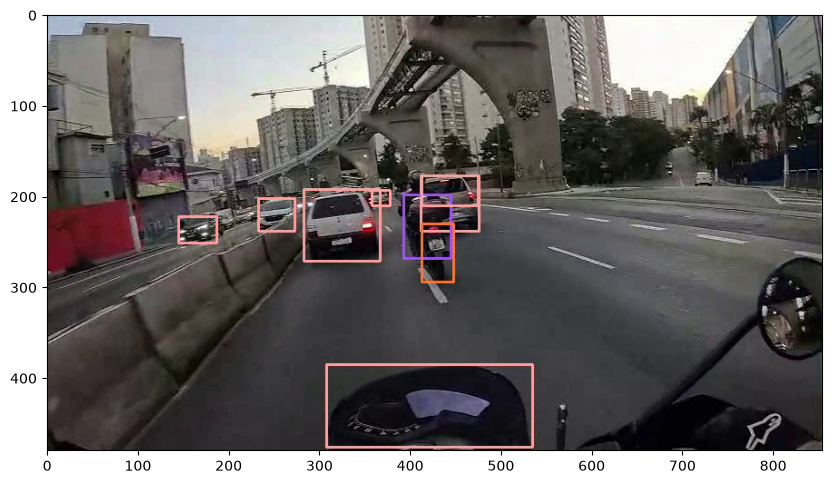

In [7]:
cap = cv2.VideoCapture('../videos/moto_480P_5sec_low.mp4_anotate.mp4')
meio = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, meio)
ok, frame = cap.read()
cap.release()
assert ok

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
# plt.axis('off')
plt.show()

#### Tracking

In [8]:
model = YOLO("yolov8n.pt")
tracker = sv.ByteTrack()
box_annotator = sv.BoxAnnotator()

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    results = model(frame)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = tracker.update_with_detections(detections)
    return box_annotator.annotate(frame.copy(), detections=detections)

sv.process_video(
    source_path="../videos/moto_480P_5sec_low.mp4",
    target_path="../videos/moto_480P_5sec_low.mp4_anotateTrack.mp4",
    callback=callback
)


0: 384x640 1 person, 1 bicycle, 9 cars, 3 motorcycles, 1 traffic light, 201.3ms
Speed: 7.0ms preprocess, 201.3ms inference, 3.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 bicycle, 9 cars, 1 motorcycle, 1 truck, 2 traffic lights, 161.4ms
Speed: 6.6ms preprocess, 161.4ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 bicycle, 8 cars, 3 motorcycles, 1 truck, 1 traffic light, 349.5ms
Speed: 6.3ms preprocess, 349.5ms inference, 4.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10 cars, 1 motorcycle, 1 truck, 2 traffic lights, 236.5ms
Speed: 12.4ms preprocess, 236.5ms inference, 5.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10 cars, 1 motorcycle, 1 truck, 225.6ms
Speed: 9.1ms preprocess, 225.6ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10 cars, 1 motorcycle, 1 truck, 182.7ms
Speed: 6.0ms preprocess, 182.7ms inference, 

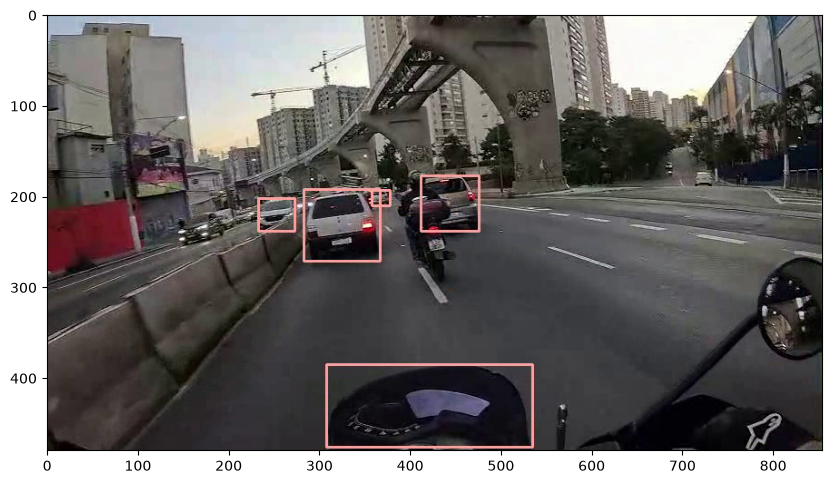

In [11]:
cap = cv2.VideoCapture('../videos/moto_480P_5sec_low.mp4_anotateTrack.mp4')
meio = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, meio)
ok, frame = cap.read()
cap.release()
assert ok

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
# plt.axis('off')
plt.show()

#### Annotate Video with Tracking IDs


In [12]:
model = YOLO("yolov8n.pt")
tracker = sv.ByteTrack()
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    results = model(frame)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = tracker.update_with_detections(detections)

    labels = [
        f"#{tracker_id} {class_name}"
        for class_name, tracker_id
        in zip(detections.data["class_name"], detections.tracker_id)
    ]

    annotated_frame = box_annotator.annotate(
        frame.copy(), detections=detections)
    return label_annotator.annotate(
        annotated_frame, detections=detections, labels=labels)

sv.process_video(
    source_path="../videos/moto_480P_5sec_low.mp4",
    target_path="../videos/moto_480P_5sec_low.mp4_anotateTrackId.mp4",
    callback=callback
)


0: 384x640 1 person, 1 bicycle, 9 cars, 3 motorcycles, 1 traffic light, 104.2ms
Speed: 4.9ms preprocess, 104.2ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 bicycle, 9 cars, 1 motorcycle, 1 truck, 2 traffic lights, 159.7ms
Speed: 3.5ms preprocess, 159.7ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 bicycle, 8 cars, 3 motorcycles, 1 truck, 1 traffic light, 120.7ms
Speed: 4.9ms preprocess, 120.7ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10 cars, 1 motorcycle, 1 truck, 2 traffic lights, 125.4ms
Speed: 4.2ms preprocess, 125.4ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10 cars, 1 motorcycle, 1 truck, 93.9ms
Speed: 4.2ms preprocess, 93.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10 cars, 1 motorcycle, 1 truck, 86.1ms
Speed: 3.1ms preprocess, 86.1ms inference, 1.7ms

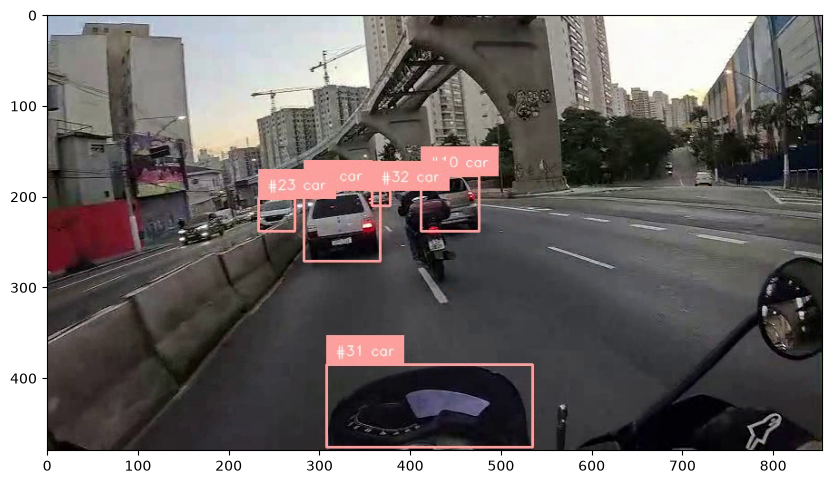

In [13]:
cap = cv2.VideoCapture('../videos/moto_480P_5sec_low.mp4_anotateTrackId.mp4')
meio = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, meio)
ok, frame = cap.read()
cap.release()
assert ok

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
# plt.axis('off')
plt.show()

#### Annotate Video with Traces

In [14]:
model = YOLO("yolov8n.pt")
tracker = sv.ByteTrack()
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()
trace_annotator = sv.TraceAnnotator()

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    results = model(frame)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = tracker.update_with_detections(detections)

    labels = [
        f"#{tracker_id} {class_name}"
        for class_name, tracker_id
        in zip(detections.data["class_name"], detections.tracker_id)
    ]

    annotated_frame = box_annotator.annotate(
        frame.copy(), detections=detections)
    annotated_frame = label_annotator.annotate(
        annotated_frame, detections=detections, labels=labels)
    return trace_annotator.annotate(
        annotated_frame, detections=detections)

sv.process_video(
    source_path="../videos/moto_480P_5sec_low.mp4",
    target_path="../videos/moto_480P_5sec_low.mp4_anotateTraces.mp4",
    callback=callback
)


0: 384x640 1 person, 1 bicycle, 9 cars, 3 motorcycles, 1 traffic light, 121.9ms
Speed: 12.8ms preprocess, 121.9ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 bicycle, 9 cars, 1 motorcycle, 1 truck, 2 traffic lights, 139.1ms
Speed: 5.0ms preprocess, 139.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 bicycle, 8 cars, 3 motorcycles, 1 truck, 1 traffic light, 126.0ms
Speed: 3.8ms preprocess, 126.0ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10 cars, 1 motorcycle, 1 truck, 2 traffic lights, 116.8ms
Speed: 4.4ms preprocess, 116.8ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10 cars, 1 motorcycle, 1 truck, 108.0ms
Speed: 3.5ms preprocess, 108.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 10 cars, 1 motorcycle, 1 truck, 101.9ms
Speed: 4.6ms preprocess, 101.9ms inference, 

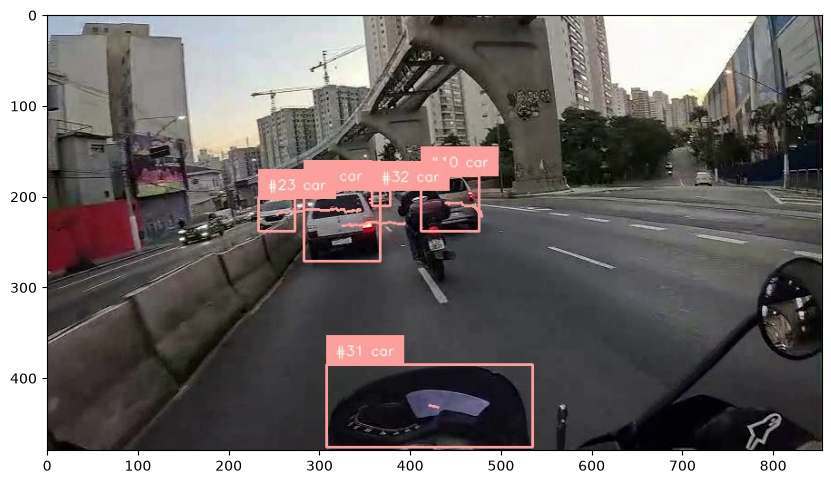

In [15]:
cap = cv2.VideoCapture('../videos/moto_480P_5sec_low.mp4_anotateTraces.mp4')
meio = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, meio)
ok, frame = cap.read()
cap.release()
assert ok

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
# plt.axis('off')
plt.show()

#### Keypoints Detection

In [16]:
model = YOLO("yolov8m-pose.pt")
edge_annotator = sv.EdgeAnnotator()
vertex_annotator = sv.VertexAnnotator()

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    results = model(frame)[0]
    key_points = sv.KeyPoints.from_ultralytics(results)

    annotated_frame = edge_annotator.annotate(
        frame.copy(), key_points=key_points)
    return vertex_annotator.annotate(
        annotated_frame, key_points=key_points)

sv.process_video(
    source_path="../videos/moto_480P_5sec_low.mp4",
    target_path="../videos/moto_480P_5sec_low.mp4_anotateKeyPoints.mp4",
    callback=callback
)


0: 384x640 2 persons, 3115.8ms
Speed: 62.1ms preprocess, 3115.8ms inference, 45.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1846.0ms
Speed: 18.0ms preprocess, 1846.0ms inference, 17.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 2625.4ms
Speed: 26.3ms preprocess, 2625.4ms inference, 11.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 3512.3ms
Speed: 16.0ms preprocess, 3512.3ms inference, 12.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 3541.3ms
Speed: 25.9ms preprocess, 3541.3ms inference, 12.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 2656.1ms
Speed: 20.9ms preprocess, 2656.1ms inference, 9.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1612.0ms
Speed: 19.5ms preprocess, 1612.0ms inference, 4.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1663.6ms
Speed: 12.9ms preprocess, 1663.6ms inference

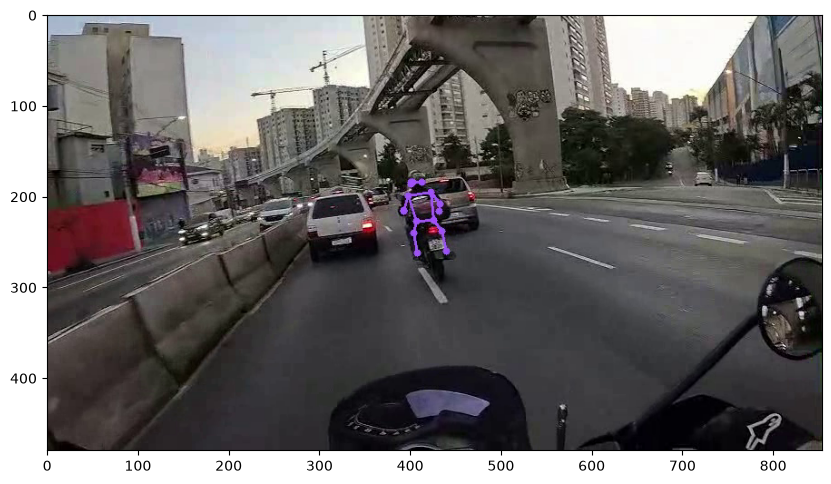

In [ ]:
cap = cv2.VideoCapture('../videos/moto_480P_5sec_low.mp4_anotateKeyPoints.mp4')
meio = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, meio)
ok, frame = cap.read()
cap.release()
assert ok

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
# plt.axis('off')
plt.show()

#### Convert to Detections¶


In [19]:
model = YOLO("yolov8m-pose.pt")
edge_annotator = sv.EdgeAnnotator()
vertex_annotator = sv.VertexAnnotator()
box_annotator = sv.BoxAnnotator()

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    results = model(frame)[0]
    key_points = sv.KeyPoints.from_ultralytics(results)
    detections = key_points.as_detections()

    annotated_frame = edge_annotator.annotate(
        frame.copy(), key_points=key_points)
    annotated_frame = vertex_annotator.annotate(
        annotated_frame, key_points=key_points)
    return box_annotator.annotate(
        annotated_frame, detections=detections)

sv.process_video(
    source_path="../videos/moto_480P_5sec_low.mp4",
    target_path="../videos/moto_480P_5sec_low.mp4_anotateDetections.mp4",
    callback=callback
)


0: 384x640 2 persons, 469.1ms
Speed: 4.1ms preprocess, 469.1ms inference, 2.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 558.9ms
Speed: 4.2ms preprocess, 558.9ms inference, 4.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 567.6ms
Speed: 4.8ms preprocess, 567.6ms inference, 2.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 554.7ms
Speed: 4.8ms preprocess, 554.7ms inference, 4.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1017.4ms
Speed: 6.8ms preprocess, 1017.4ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1850.6ms
Speed: 11.6ms preprocess, 1850.6ms inference, 8.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1122.3ms
Speed: 11.4ms preprocess, 1122.3ms inference, 5.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 883.0ms
Speed: 15.0ms preprocess, 883.0ms inference, 2.4ms postprocess 

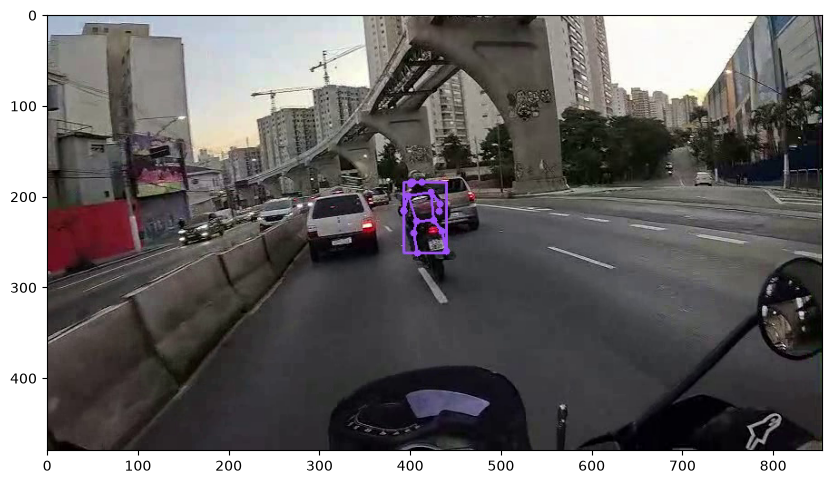

In [20]:
cap = cv2.VideoCapture('../videos/moto_480P_5sec_low.mp4_anotateDetections.mp4')
meio = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, meio)
ok, frame = cap.read()
cap.release()
assert ok

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
# plt.axis('off')
plt.show()

#### Keypoint Tracking

In [21]:
model = YOLO("yolov8m-pose.pt")
edge_annotator = sv.EdgeAnnotator()
vertex_annotator = sv.VertexAnnotator()
box_annotator = sv.BoxAnnotator()

tracker = sv.ByteTrack()
trace_annotator = sv.TraceAnnotator()

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    results = model(frame)[0]
    key_points = sv.KeyPoints.from_ultralytics(results)
    detections = key_points.as_detections()
    detections = tracker.update_with_detections(detections)

    annotated_frame = edge_annotator.annotate(
        frame.copy(), key_points=key_points)
    annotated_frame = vertex_annotator.annotate(
        annotated_frame, key_points=key_points)
    annotated_frame = box_annotator.annotate(
        annotated_frame, detections=detections)
    return trace_annotator.annotate(
        annotated_frame, detections=detections)

sv.process_video(
    source_path="../videos/moto_480P_5sec_low.mp4",
    target_path="../videos/moto_480P_5sec_low.mp4_anotateKeyPointTracking.mp4",
    callback=callback
)


0: 384x640 2 persons, 575.2ms
Speed: 5.7ms preprocess, 575.2ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 650.8ms
Speed: 4.1ms preprocess, 650.8ms inference, 5.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 641.6ms
Speed: 9.6ms preprocess, 641.6ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 463.1ms
Speed: 4.9ms preprocess, 463.1ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 498.0ms
Speed: 4.2ms preprocess, 498.0ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 452.7ms
Speed: 4.5ms preprocess, 452.7ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 517.3ms
Speed: 3.1ms preprocess, 517.3ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 758.9ms
Speed: 6.6ms preprocess, 758.9ms inference, 1.8ms postprocess per image

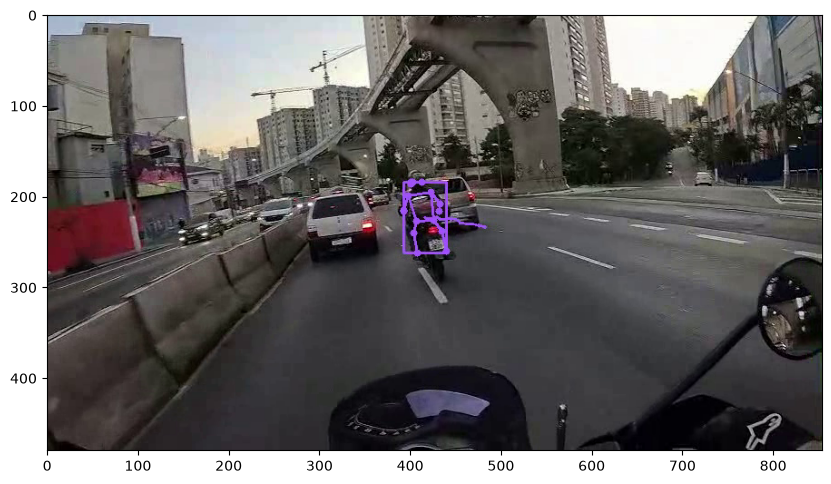

In [22]:
cap = cv2.VideoCapture('../videos/moto_480P_5sec_low.mp4_anotateKeyPointTracking.mp4')
meio = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, meio)
ok, frame = cap.read()
cap.release()
assert ok

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
# plt.axis('off')
plt.show()

#### Bonus: Smoothing

In [23]:
model = YOLO("yolov8m-pose.pt")
edge_annotator = sv.EdgeAnnotator()
vertex_annotator = sv.VertexAnnotator()
box_annotator = sv.BoxAnnotator()

tracker = sv.ByteTrack()
smoother = sv.DetectionsSmoother()
trace_annotator = sv.TraceAnnotator()

def callback(frame: np.ndarray, _: int) -> np.ndarray:
    results = model(frame)[0]
    key_points = sv.KeyPoints.from_ultralytics(results)
    detections = key_points.as_detections()
    detections = tracker.update_with_detections(detections)
    detections = smoother.update_with_detections(detections)

    annotated_frame = edge_annotator.annotate(
        frame.copy(), key_points=key_points)
    annotated_frame = vertex_annotator.annotate(
        annotated_frame, key_points=key_points)
    annotated_frame = box_annotator.annotate(
        annotated_frame, detections=detections)
    return trace_annotator.annotate(
        annotated_frame, detections=detections)

sv.process_video(
    source_path="../videos/moto_480P_5sec_low.mp4",
    target_path="../videos/moto_480P_5sec_low.mp4_anotateSmoothing.mp4",
    callback=callback
)


0: 384x640 2 persons, 1416.7ms
Speed: 8.0ms preprocess, 1416.7ms inference, 6.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1270.2ms
Speed: 29.9ms preprocess, 1270.2ms inference, 3.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 persons, 1083.4ms
Speed: 7.7ms preprocess, 1083.4ms inference, 4.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1115.1ms
Speed: 9.3ms preprocess, 1115.1ms inference, 5.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1468.7ms
Speed: 11.9ms preprocess, 1468.7ms inference, 6.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1137.7ms
Speed: 24.8ms preprocess, 1137.7ms inference, 3.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 842.7ms
Speed: 7.6ms preprocess, 842.7ms inference, 3.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 758.9ms
Speed: 7.4ms preprocess, 758.9ms inference, 3.5ms postpr

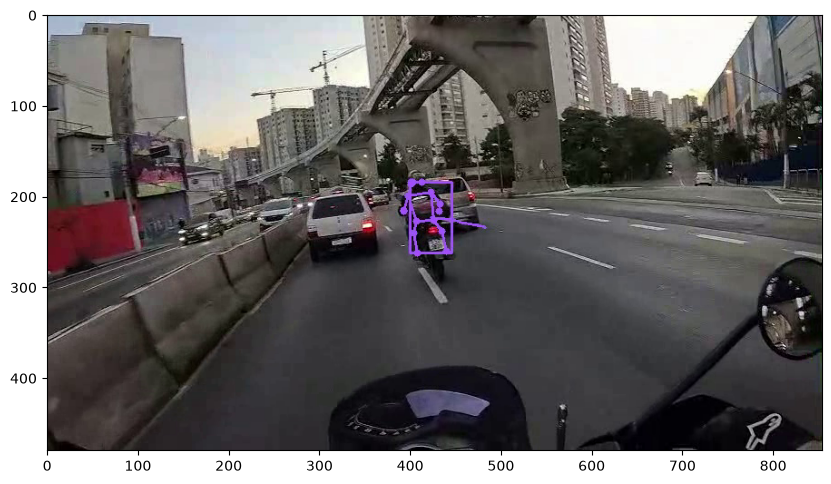

In [24]:
cap = cv2.VideoCapture('../videos/moto_480P_5sec_low.mp4_anotateSmoothing.mp4')
meio = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) // 2
cap.set(cv2.CAP_PROP_POS_FRAMES, meio)
ok, frame = cap.read()
cap.release()
assert ok

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
# plt.axis('off')
plt.show()